# 神经网络参数初始化实验 🧠

## 学习目标 🎯

完成本实验后，你将能够：

- 理解参数初始化对神经网络训练的重要性
- 实现**零初始化**并观察其失败原因（对称性问题）
- 实现**随机初始化**并理解大初始值带来的问题
- 实现 **He 初始化**，掌握适合 ReLU 网络的缩放方法
- 通过实验对比三种初始化方法的效果

> 💡 良好的参数初始化是神经网络训练成功的基础，错误的初始化会导致梯度消失、梯度爆炸或对称性失效等问题。

## 目录

- [1 - 导入包](#1)
- [2 - 数据集加载](#2)
- [3 - 神经网络模型](#3)
- [4 - 零初始化](#4)
    - [练习 1 - initialize_parameters_zeros](#ex-1)
- [5 - 随机初始化](#5)
    - [练习 2 - initialize_parameters_random](#ex-2)
- [6 - He 初始化](#6)
    - [练习 3 - initialize_parameters_he](#ex-3)
- [7 - 总结](#7)

<a name='1'></a>
## 1 - 导入包 📦

In [33]:
### v1.0

In [34]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = [
    'PingFang SC',        # macOS
    'Hiragino Sans GB',   # macOS（备用）
    'Microsoft YaHei',    # Windows
    'SimHei',             # Windows（备用）
    'Noto Sans CJK SC',   # Linux / 通用
    'Arial Unicode MS'    # 兜底
]

plt.rcParams['axes.unicode_minus'] = False

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from public_tests import *
from init_utils import sigmoid, relu, compute_loss, forward_propagation, backward_propagation, \
    update_parameters, predict, load_dataset, plot_decision_boundary, predict_dec

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<a name='2'></a>
## 2 - 数据集加载 📊

本实验使用**二维月牙形（moons）数据集**。该数据集由两个弯月形分布的类别组成，是验证分类器性能的经典基准。

**任务**：将蓝色点和红色点正确分类。

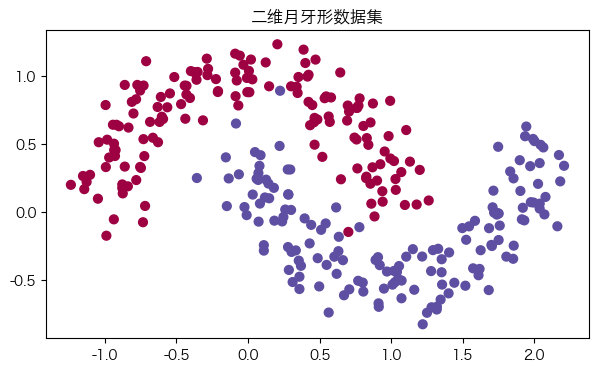

In [36]:
train_X, train_Y, test_X, test_Y = load_dataset()

<a name='3'></a>
## 3 - 神经网络模型 🔧

我们使用一个**三层全连接神经网络**（已为你实现）：

$$\text{LINEAR} \to \text{ReLU} \to \text{LINEAR} \to \text{ReLU} \to \text{LINEAR} \to \text{Sigmoid}$$

你将在以下三种初始化方式之间切换，通过 `initialization` 参数控制：
- `"zeros"` — 零初始化
- `"random"` — 大随机数初始化
- `"he"` — He 初始化

In [37]:
def model(X, Y, learning_rate=0.01, num_iterations=15000, print_cost=True, initialization="he"):
    """
    三层神经网络训练函数：LINEAR->RELU->LINEAR->RELU->LINEAR->SIGMOID。
    
    参数：
    X -- 输入数据，形状 (输入维度, 样本数)
    Y -- 标签向量，形状 (1, 样本数)
    learning_rate -- 学习率
    num_iterations -- 训练迭代次数
    print_cost -- 是否打印代价
    initialization -- 初始化方式："zeros"/"random"/"he"
    
    返回：
    parameters -- 训练后的参数字典
    """
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 10, 5, 1]

    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)

    for i in range(num_iterations):
        a3, cache = forward_propagation(X, parameters)
        cost = compute_loss(a3, Y)
        grads = backward_propagation(X, Y, cache)
        parameters = update_parameters(parameters, grads, learning_rate)

        if print_cost and i % 1000 == 0:
            print("第 %i 次迭代，代价：%f" % (i, cost))
            costs.append(cost)

    plt.plot(costs)
    plt.ylabel('代价')
    plt.xlabel('迭代次数（每1000次）')
    plt.title("学习曲线（初始化方式：" + initialization + "）")
    plt.show()

    return parameters

<a name='4'></a>
## 4 - 零初始化 🚫

将所有权重矩阵 $W^{[l]}$ 初始化为全零是最简单的方案，但它会导致严重问题。

**为什么零初始化会失败？**

当所有权重相等时，每一层中所有神经元的输出完全相同，梯度也完全相同。这意味着无论训练多少轮，所有神经元始终保持对称，网络无法学到不同的特征。

| 参数 | 初始值 |
|------|--------|
| $W^{[l]}$ | 零矩阵 |
| $b^{[l]}$ | 零向量 |

<a name='ex-1'></a>
### 练习 1 — `initialize_parameters_zeros`

实现**零初始化**函数。

**提示**：
- 权重矩阵 $W^{[l]}$ 形状：`(layer_dims[l], layer_dims[l-1])`，用 `np.zeros()` 初始化
- 偏置向量 $b^{[l]}$ 形状：`(layer_dims[l], 1)`，用 `np.zeros()` 初始化
- 用 `'W' + str(l)` 作为字典键名，`l` 从 1 到 `L`

**思考**：零初始化的权重矩阵有什么问题？它和偏置为零有什么本质区别？

In [38]:
# GRADED FUNCTION: initialize_parameters_zeros

def initialize_parameters_zeros(layers_dims):
    """
    将所有参数初始化为零。
    
    参数：
    layers_dims -- 各层维度列表，例如 [2, 4, 1] 表示输入2个特征、隐藏层4个神经元、输出1个
    
    返回：
    parameters -- 参数字典，包含 W1, b1, ..., WL, bL（全为零）
    """
    parameters = {}
    L = len(layers_dims)

    for l in range(1, L):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return parameters

In [39]:
parameters = initialize_parameters_zeros([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
initialize_parameters_zeros_test(initialize_parameters_zeros)

W1 = [[0. 0. 0.]
 [0. 0. 0.]]
b1 = [[0.]
 [0.]]
W2 = [[0. 0.]]
b2 = [[0.]]
 All tests passed.


使用零初始化训练模型，观察结果：

第 0 次迭代，代价：0.693147
第 1000 次迭代，代价：0.693147
第 2000 次迭代，代价：0.693147
第 3000 次迭代，代价：0.693147
第 4000 次迭代，代价：0.693147
第 5000 次迭代，代价：0.693147
第 6000 次迭代，代价：0.693147
第 7000 次迭代，代价：0.693147
第 8000 次迭代，代价：0.693147
第 9000 次迭代，代价：0.693147
第 10000 次迭代，代价：0.693147
第 11000 次迭代，代价：0.693147
第 12000 次迭代，代价：0.693147
第 13000 次迭代，代价：0.693147
第 14000 次迭代，代价：0.693147


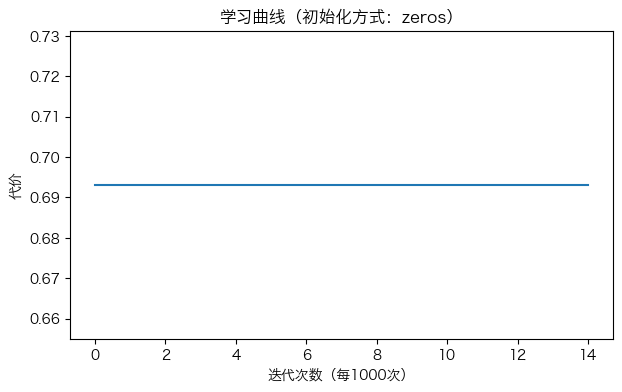

训练集上：
准确率：0.5
测试集上：
准确率：0.5


In [40]:
parameters = model(train_X, train_Y, initialization="zeros")
print("训练集上：")
predictions_train = predict(train_X, train_Y, parameters)
print("测试集上：")
predictions_test = predict(test_X, test_Y, parameters)

In [41]:
print("predictions_train = " + str(predictions_train))
print("predictions_test  = " + str(predictions_test))

predictions_train = [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0]]
predictions_test  = [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


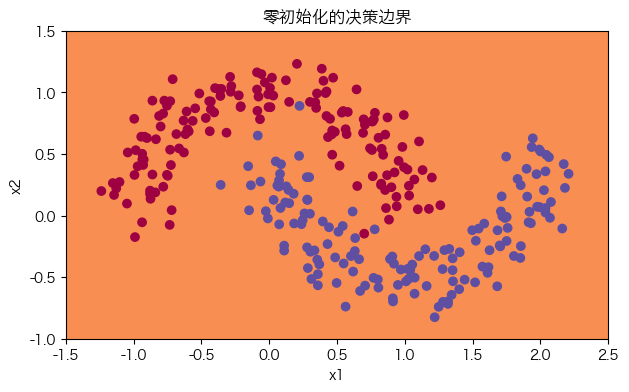

In [42]:
plt.title("零初始化的决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1.0, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**观察**：模型无法学习，准确率约为 50%，决策边界是一条直线。

> 🔑 **记忆要点**：
> - 权重 $W^{[l]}$ **必须随机初始化**以打破对称性
> - 偏置 $b^{[l]}$ 初始化为零是可以的（不会引起对称性问题）

<a name='5'></a>
## 5 - 随机初始化 🎲

为打破对称性，将权重初始化为较大的随机值。虽然解决了对称性问题，但过大的初始权重会导致：
- 最后一层激活值（sigmoid）饱和，输出接近 0 或 1
- 损失函数出现 `log(接近0)` 的情况，引发数值溢出（`inf`）
- 梯度在反向传播中消失

**初始化方式**：$W^{[l]} = \text{np.random.randn}(\ldots) \times 10$

<a name='ex-2'></a>
### 练习 2 — `initialize_parameters_random`

实现**大随机数初始化**函数。

**提示**：
- 权重用 `np.random.randn()` 生成，然后乘以 **10**（故意放大以观察问题）
- 偏置仍然初始化为零
- 每层开始前设置随机种子：`np.random.seed(l)`

**思考**：为什么过大的初始权重会导致梯度爆炸或梯度消失？

In [43]:
# GRADED FUNCTION: initialize_parameters_random

def initialize_parameters_random(layers_dims):
    """
    将权重初始化为较大的随机值（用于演示问题）。
    
    参数：
    layers_dims -- 各层维度列表
    
    返回：
    parameters -- 参数字典，W 用大随机数，b 为零
    """
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims)
    
    for l in range(1, L):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return parameters

In [44]:
parameters = initialize_parameters_random([3, 2, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
initialize_parameters_random_test(initialize_parameters_random)

W1 = [[ 17.88628473   4.36509851   0.96497468]
 [-18.63492703  -2.77388203  -3.54758979]]
b1 = [[0.]
 [0.]]
W2 = [[-0.82741481 -6.27000677]]
b2 = [[0.]]
 All tests passed.


使用大随机数初始化训练模型：

第 0 次迭代，代价：inf
第 1000 次迭代，代价：0.705932
第 2000 次迭代，代价：0.533884
第 3000 次迭代，代价：0.350170
第 4000 次迭代，代价：0.376649
第 5000 次迭代，代价：0.319939
第 6000 次迭代，代价：0.310778
第 7000 次迭代，代价：0.309390
第 8000 次迭代，代价：0.314567
第 9000 次迭代，代价：0.320350
第 10000 次迭代，代价：0.312149
第 11000 次迭代，代价：0.306078
第 12000 次迭代，代价：0.301821
第 13000 次迭代，代价：0.297556
第 14000 次迭代，代价：0.290917


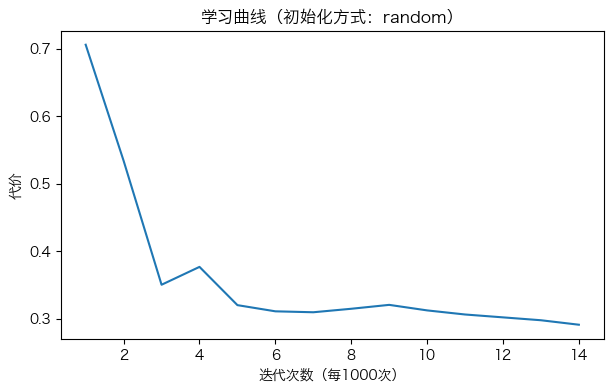

训练集上：
准确率：0.87
测试集上：
准确率：0.86


In [45]:
parameters = model(train_X, train_Y, initialization="random")
print("训练集上：")
predictions_train = predict(train_X, train_Y, parameters)
print("测试集上：")
predictions_test = predict(test_X, test_Y, parameters)

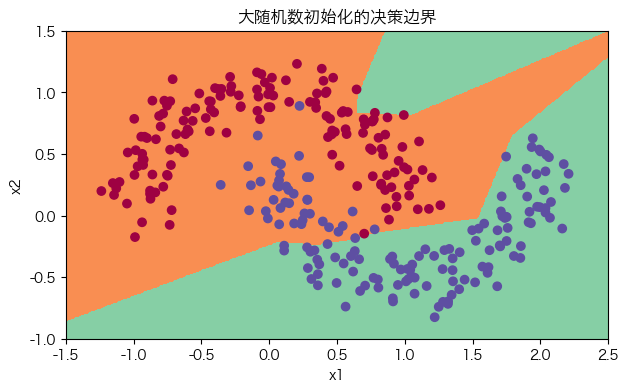

In [46]:
plt.title("大随机数初始化的决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1.0, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**观察**：
- 初始代价非常高（可能出现 `inf`），因为大权重使 sigmoid 饱和
- 最终模型能收敛，但性能不如 He 初始化

> 🔑 **关键点**：过大的随机初始权重会导致初始损失极高，训练不稳定。

<a name='6'></a>
## 6 - He 初始化 ⚡

**He 初始化**（来自 He et al., 2015）专为使用 **ReLU** 激活函数的深度网络设计。

**核心思想**：将权重随机值除以 $\sqrt{n^{[l-1]}}$（前一层的神经元数量），使得每层输出方差接近 1，避免梯度消失/爆炸。

$$W^{[l]} = \text{np.random.randn}(\ldots) \times \sqrt{\frac{2}{n^{[l-1]}}}$$

其中 $n^{[l-1]} = $ `layers_dims[l-1]`。

**与 Xavier 初始化的区别**：
- Xavier：乘以 $\sqrt{\frac{1}{n^{[l-1]}}}$，适合 tanh 激活
- He：乘以 $\sqrt{\frac{2}{n^{[l-1]}}}$，适合 ReLU 激活（因为 ReLU 将一半输入置零）

<a name='ex-3'></a>
### 练习 3 — `initialize_parameters_he`

实现 **He 初始化**函数。

**提示**：
- 公式：$W^{[l]} = \text{np.random.randn}(layers\_dims[l], layers\_dims[l-1]) \times \sqrt{\frac{2}{layers\_dims[l-1]}}$
- 用 `np.sqrt(2. / layers_dims[l-1])` 计算缩放因子
- 偏置仍然初始化为零

**思考**：为什么分子是 2 而不是 1？（提示：考虑 ReLU 对激活值的影响）

In [47]:
# GRADED FUNCTION: initialize_parameters_he

def initialize_parameters_he(layers_dims):
    """
    He 初始化：适合 ReLU 激活函数的深度网络。
    
    参数：
    layers_dims -- 各层维度列表
    
    返回：
    parameters -- 参数字典，使用 He 初始化
    """
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims) - 1

    for l in range(1, L + 1):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return parameters

In [48]:
parameters = initialize_parameters_he([2, 4, 1])
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))
initialize_parameters_he_test(initialize_parameters_he)

W1 = [[ 1.78862847  0.43650985]
 [ 0.09649747 -1.8634927 ]
 [-0.2773882  -0.35475898]
 [-0.08274148 -0.62700068]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[-0.03098412 -0.33744411 -0.92904268  0.62552248]]
b2 = [[0.]]
 All tests passed.


使用 He 初始化训练模型：

第 0 次迭代，代价：0.729689
第 1000 次迭代，代价：0.315404
第 2000 次迭代，代价：0.280508
第 3000 次迭代，代价：0.256156
第 4000 次迭代，代价：0.233641
第 5000 次迭代，代价：0.204610
第 6000 次迭代，代价：0.168703
第 7000 次迭代，代价：0.126987
第 8000 次迭代，代价：0.093100
第 9000 次迭代，代价：0.071222
第 10000 次迭代，代价：0.057110
第 11000 次迭代，代价：0.048252
第 12000 次迭代，代价：0.042325
第 13000 次迭代，代价：0.038193
第 14000 次迭代，代价：0.035234


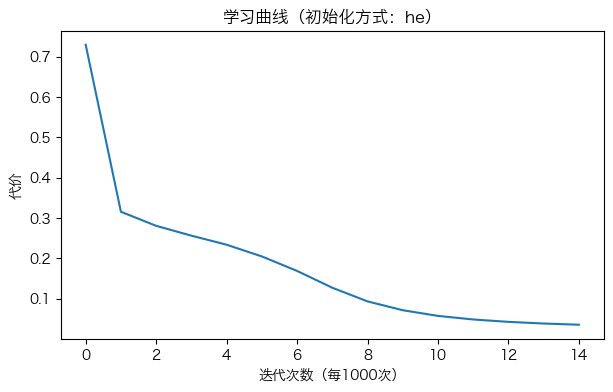

训练集上：
准确率：0.9933333333333333
测试集上：
准确率：1.0


In [49]:
parameters = model(train_X, train_Y, initialization="he")
print("训练集上：")
predictions_train = predict(train_X, train_Y, parameters)
print("测试集上：")
predictions_test = predict(test_X, test_Y, parameters)

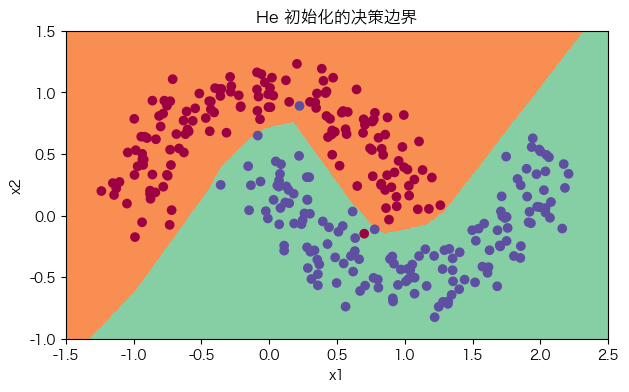

In [50]:
plt.title("He 初始化的决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1.0, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

**观察**：He 初始化的模型能在较少的迭代次数内收敛，决策边界更准确。

<a name='7'></a>
## 7 - 总结 📋

三种初始化方法的对比：

| 初始化方式 | 训练准确率 | 测试准确率 | 问题 |
|-----------|-----------|-----------|------|
| 零初始化  | ~50%      | ~50%      | 对称性破坏失败 |
| 大随机数  | 较高       | 中等       | 初始损失极高，训练不稳定 |
| He 初始化 | 高         | 高         | 无明显问题 |

> 🔑 **本实验的关键结论**：
> - 权重初始化**不能全为零**（对称性问题）
> - 权重初始化**不能过大**（数值不稳定）
> - 对于使用 **ReLU** 激活的网络，推荐使用 **He 初始化**
> - 对于使用 **tanh** 激活的网络，推荐使用 **Xavier 初始化**